In [1]:
import pandas as pd 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

In [2]:
df = pd.read_csv("salaries.csv")
print(df.head())

   years_of_experience  city  salary
0                    5     1    3150
1                    9     1    3787
2                    4     2    2991
3                   10     1    4551
4                    8     2    3540


In [3]:
x = df[['years_of_experience','city']]
print(x)
y = df ['salary']
print (y)

    years_of_experience  city
0                     5     1
1                     9     1
2                     4     2
3                    10     1
4                     8     2
..                  ...   ...
95                    4     1
96                    4     2
97                    2     2
98                    7     1
99                    2     2

[100 rows x 2 columns]
0     3150
1     3787
2     2991
3     4551
4     3540
      ... 
95    2884
96    2810
97    2488
98    3661
99    2496
Name: salary, Length: 100, dtype: int64


In [4]:
x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [5]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
pred_y = model.predict(x_test)
print("coefficient (b1) : " , model.coef_)
print("intercept (b0) : " , model.intercept_)
print(" R2 score : " , r2_score(y_test , pred_y))
print("MSE : ", mean_squared_error(y_test,pred_y))


coefficient (b1) :  [ 189.79543252 -294.26061721]
intercept (b0) :  2683.2014189776
 R2 score :  0.9533918178512795
MSE :  16947.021669595


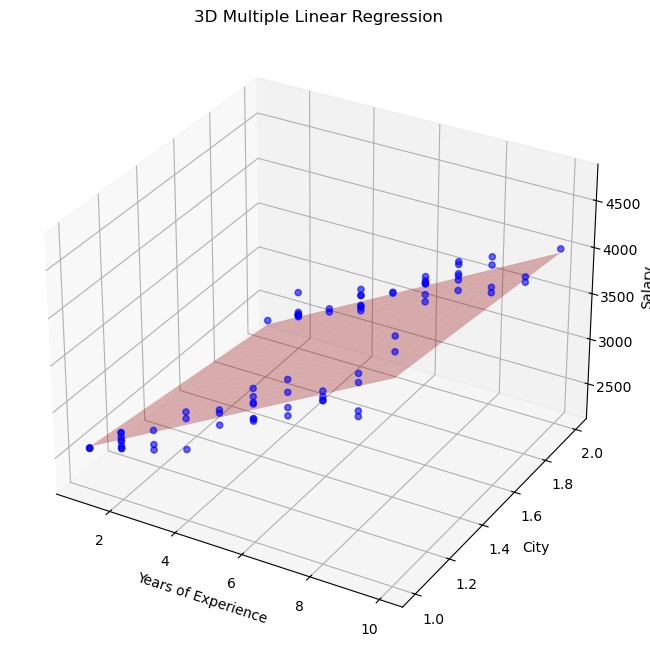

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_train.iloc[:, 0], x_train.iloc[:, 1], y_train, color='blue', alpha=0.6, label='real data ')

x_surf = np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 20)
y_surf = np.linspace(x.iloc[:, 1].min(), x.iloc[:, 1].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

combined_surf = pd.DataFrame({'years_of_experience': x_surf.ravel(), 'city': y_surf.ravel()})
z_surf = model.predict(combined_surf).reshape(x_surf.shape)

ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3)

ax.set_xlabel('Years of Experience')
ax.set_ylabel('City')
ax.set_zlabel('Salary')
ax.set_title('3D Multiple Linear Regression')

plt.show()

In [8]:
import joblib 

joblib.dump(model, "salary_3d_model.pkl")
print("suvgard avec succes")

suvgard avec succes
